# EDA - Eploratory Data Analysis

**Role:** Performs Exploratory Data Analysis (EDA) on the historical BDIFF fire datasets from 2006 onwards. Generates descriptive statistics, temporal evolutions, seasonality distributions, and geographical hotspots to identify baseline fire patterns.

**Inputs:**
- Cleaned parquet files: `data/bdiff_data_clean/incendies.parquet` (or `incendies_metropole_corse.parquet`)
- Cleaned geo files: `data/geo_data_clean/communes_metropole_corse.parquet`
- Processed data: `data/spatio_temp/df_spatio_temp.parquet`

**Outputs:**
- Interactive folium maps, seaborn/matplotlib statistical charts (exported to `figures/`)
- Data insights for future spatial and temporal modeling

## Exploratory Data Analysis Steps

- Load cleaned data directly from the PostgreSQL database, focusing strictly on the PACA region from 2016 onwards (using `incendies.v_commune_paca` and `incendies.incendie` tables)[cite: 12, 14].
- Merge fire events with municipalities data using the `code_insee` key.
- Create temporal features: year, month, day, and convert burnt surface into hectares.
- Add calendar indicators: weekends, public holidays, school holidays, and non-working days.
- Define constants and mapping parameters for geospatial visualization.
- Visualize the geographical distribution of fires per year across the PACA region.
- Visualize fire intensity hotspots, weighted by the burnt surface area.
- Analyze annual trends and monthly seasonality.
- Study the distribution of burnt surface areas using a logarithmic scale.
- Compare fire occurrences during school holidays, weekends, and public holidays versus regular working days.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

import holidays
from vacances_scolaires_france import SchoolHolidayDates

import folium
from folium.plugins import HeatMap, MarkerCluster
import matplotlib.pyplot as plt


# Utiliser une police générique reconnue partout
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'

# import plotly.io as pio pio.renderers.default = "notebook\_connected"

import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from IPython.display import HTML, IFrame, display
import base64

# import holidays
# from vacances_scolaires_france import SchoolHolidayDates


# adds parent file of the current directory
# to the paths in which Python looks for modules to import
# in the current Python process
sys.path.append(str(Path.cwd().parent))

from src.config import BDIFF_RAW_DIR, DATA_DIR, BDIFF_CLEAN_DIR, GEO_DATA_CLEAN_DIR, SPATIO_TEMP_DATA_DIR, FIGURES_DIR
from utils.cleaning_utils import delete, normalize_columns_names, normalize_text_columns_cells, optimize_numeric_column, fill_rate
from utils.analysis_utils import plot_missing_bar, plot_numeric_histograms, plot_corr_heatmap, plot_qualitative

In [2]:
df_incendies = pd.read_parquet(
    BDIFF_CLEAN_DIR / "incendies.parquet"
)

df_communes = pd.read_parquet(
    GEO_DATA_CLEAN_DIR / "communes_metropole_corse.parquet"
)

df = df_incendies.merge(
    df_communes,
    on="code_insee",
    how="left"
)

df_spatio_temp = pd.read_parquet(
    SPATIO_TEMP_DATA_DIR / "df_spatio_temp.parquet"
)

In [3]:
df['annee'] = df['date_de_premiere_alerte'].dt.year
df['mois'] = df['date_de_premiere_alerte'].dt.month
df['jours'] = df['date_de_premiere_alerte'].dt.day

#conversion de la surface en hectares (1ha = 10000 m2)
df['surface_parcourue_ha'] = df['surface_parcourue_m2'] / 10_000

# Filtrage des feux avec surface > 0
df_pos = df[df["surface_parcourue_m2"] > 0].copy()
AVAILABLE_YEARS = [int(y) for y in sorted(df['annee'].dropna().unique())]

# Aggregation par année
df_yearly = (
    df.groupby('annee')
    .agg(
        nb_feux=('date_de_premiere_alerte', 'count'),
        total_surface_ha=('surface_parcourue_ha', 'sum'),
        mean_surface_ha=('surface_parcourue_ha', 'mean'),
        median_surface_ha=('surface_parcourue_ha', 'median'),
    )
    .reset_index()
)

#  Week-ends (5 = Samedi, 6 = Dimanche)
df['is_weekend'] = df['date_de_premiere_alerte'].dt.dayofweek >= 5

# Jours Fériés
fr_holidays = holidays.France(years=range(2011, 2026))
df['is_ferie'] = df['date_de_premiere_alerte'].dt.date.isin(fr_holidays)

# Jour non travaillé (Week-end ou Férié)
df['is_day_off'] = df['is_weekend'] | df['is_ferie']

# Instanciation du calendrier des vacances scolaires
school_holidays = SchoolHolidayDates()

unique_dates = pd.Series(df['date_de_premiere_alerte'].dt.date.dropna().unique())

# 2. Création du dictionnaire {date: True/False} (toutes zones confondues en France)
vacances_dict = dict(zip(
    unique_dates,
    unique_dates.apply(lambda d: school_holidays.is_holiday(d))
))

# application sur l'ensemble du DataFrame
df['is_holyday'] = df['date_de_premiere_alerte'].dt.date.map(vacances_dict).fillna(False)

### CONSTANTES CARTOGRAPHIQUE

In [9]:
# Centrage sur la France métropolitaine
LAT_MIN, LAT_MAX = 41.3, 51.1
LON_MIN, LON_MAX = -5.5, 9.8

MAP_CENTER = [46.5, 2.5]
MAP_ZOOM = 6


# mois
MONTH_NAMES = ["Jan","Fev","Mar","Avr","Mai","Juin","Juil","Aout","Sep","Oct","Nov","Dec"]


# Paramétrage de l'affichage des cartes
FIRE_GRADIENT = {
    # Orange clair (faible densité)
    0.2: '#ffaa00',
    # Orange vif (densité moyenne)
    0.5: '#ff5500',
    # Violet / Pourpre (forte densité)
    0.8: '#9900cc',
    # Violet très foncé / Indigo (très forte densité)
    1.0: '#4b0082'
    }

HEATMAP_CONFIG = {
     'radius': 10,
     'blur': 5,
     # Conserve la visibilité des points au zoom
     'min_opacity': 0.85,
     # Maintient l'intensité jusqu'au zoom maximal
     'max_zoom': 18,
     'gradient': FIRE_GRADIENT
    }

TILES_SERVER = {
    "OpenStreetMap": {
        'tiles' : 'OpenStreetMap',
        'attr': None
    },
    'Esri Satellite': {
        'tiles' : 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
        'attr': 'Esri World imagery'
    },
    'CartDB Voyager': {
        'tiles' : 'https://{s}.basemaps.cartocdn.com/rastertiles/voyager/{z}/{x}/{y}{r}.png',
        'attr': 'CARTO'
    },
    'OpenTopoMap': {
        'tiles' : 'https://{s}.tile.opentopomap.org/{z}/{x}/{y}.png',
        'attr': 'OpenTopoMap'
    }
}

MAP_TITLE_TEMPLATE ="""
<div style="
    position: fixed;
    top: 12px;
    left: 60px;
    z-index: 9999;
    font-family: 'Helvetica Neue', Arial, sans-serif;
    font-size: 16px;
    font-weight: 700;
    color: darkorange;
    background-color: rgba(255, 255, 255, 0.85);
    padding: 8px 14px;
    border-radius: 6px;
    box-shadow: 0 2px 6px rgba(0,0,0,0.2);
    border: 1px solid #cccccc;
">
    {title}
</div>
"""

def add_map_title(map_object, title):
    """Add a title to a folium map object."""
    title_html = MAP_TITLE_TEMPLATE.format(title=title)
    map_object.get_root().html.add_child(folium.Element(title_html))



### Carte 1 — Incendies

In [10]:
m = folium.Map(location=MAP_CENTER, zoom_start=MAP_ZOOM, tiles=None)

for name, config in TILES_SERVER.items():
        folium.TileLayer(
                tiles=config['tiles'],
                attr=config['attr'],
                name=name
        ).add_to(m)


for year in AVAILABLE_YEARS:
    df_year = df[df['annee'] == year]
    heat_data_year = df_year[['latitude', 'longitude']].dropna().values.tolist()
    # Affiche uniquement la dernière année par défaut
    is_show= (year == max(AVAILABLE_YEARS))

    group = folium.FeatureGroup(
          name=f'{year} : ({len(heat_data_year)} feux)',
          show=is_show
          )

    # Dépaquetage des paramètres avec **HEATMAP_CONFIG**
    HeatMap(
          heat_data_year,
          **HEATMAP_CONFIG
          ).add_to(group)

    group.add_to(m)

# 5. Sélecteur de couches
folium.LayerControl(position='topright',
                    collapsed=True
                    ).add_to(m)

add_map_title(m, "Répartition des incendies en France métropolitaine et Corse")

m

### Carte 2 — Intensité (Pondérée par la surface brûlée)

In [11]:
# 1. Préparation des données pondérées
df_surf = df.dropna(subset=['latitude', 'longitude', 'surface_parcourue_m2']).copy()
df_surf = df_surf[df_surf['surface_parcourue_m2'] > 0]

# Transformation log et normalisation entre 0 et 1
df_surf['weight'] = np.log1p(df_surf['surface_parcourue_m2'])
df_surf['weight'] = df_surf['weight'] / df_surf['weight'].max()

# Initialisation de la carte
m_int = folium.Map(location=MAP_CENTER, zoom_start=MAP_ZOOM, tiles=None)

# Ajout des fonds de carte
for name, config in TILES_SERVER.items():
    folium.TileLayer(
        tiles=config['tiles'],
        attr=config['attr'],
        name=name
    ).add_to(m_int)

for year in AVAILABLE_YEARS:
    df_year = df_surf[df_surf['annee'] == year]

    # Données avec poids [latitude, longitude, weight]
    heat_data_weighted = df_year[['latitude', 'longitude', 'weight']].values.tolist()
    is_show = (year == max(AVAILABLE_YEARS))

    group = folium.FeatureGroup(
        name=f'Intensité{year} : ({len(heat_data_weighted)} feux)',
        show=is_show
    )

    HeatMap(
        heat_data_weighted,
        **HEATMAP_CONFIG
    ).add_to(group)

    group.add_to(m_int)

# 6. Sélecteur de couches
folium.LayerControl(position='topright', collapsed=False).add_to(m_int)

add_map_title(m_int, "Répartition des incendies selon leur intensité")

m_int

### Analyse temporelle et saisonnière - `df_yearly` et `surface_parcourue_ha`

In [12]:
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Helvetica Neue, Arial, sans-serif"


### Évolution annuelle (2006–2025)

findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.

findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.

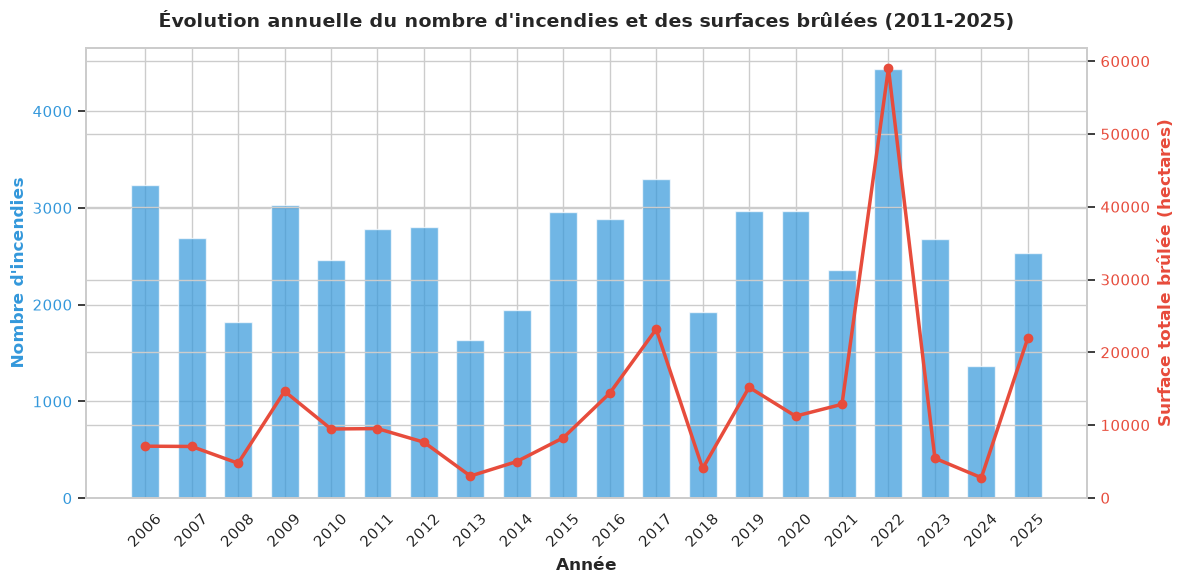

In [13]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Axe 1 : Barres du nombre d'incendies
colors_bars = "#3498db"
ax1.bar(
    df_yearly['annee'],
    df_yearly['nb_feux'],
    color=colors_bars,
    alpha=0.7,
    width=0.6,
    label="Nombre d'incendies"
)
ax1.set_xlabel("Année", fontsize=12, fontweight="bold")
ax1.set_ylabel("Nombre d'incendies",
               color=colors_bars,
               fontsize=12,
               fontweight="bold")
ax1.tick_params(axis="y", labelcolor=colors_bars)
ax1.set_xticks(df_yearly["annee"])
ax1.set_xticklabels(df_yearly["annee"].astype(int),
                    rotation=45
                    )
# Axe 2 : Ligne de la surface totale brulee (ha)
ax2 = ax1.twinx()
color_line = "#e74c3c"
ax2.plot(
    df_yearly["annee"],
    df_yearly["total_surface_ha"],
    color=color_line, marker="o",
    linewidth=2.5, markersize=6,
    label="Surface brûlée (ha)"
    )
ax2.set_ylabel( "Surface totale brûlée (hectares)",
               color=color_line,
               fontsize=12,
               fontweight="bold"
               )
ax2.tick_params(axis="y", labelcolor=color_line)

plt.title(
    "Évolution annuelle du nombre d'incendies et des surfaces brûlées (2011-2025)",
    fontsize=14,
    fontweight="bold",
    pad=15, )

plt.tight_layout()


### Évolution annuelle (2011–2025)

* **Variabilité extrême et année record** :<br>
L'année **2022** ressort nettement comme une année exceptionnelle<br>
cumulant un pic d'environ **4 400 incendies** et près de **60 000 hectares brûlés**

* **Disparité volume / dégâts** :<br>
Le nombre annuel d'incendies oscille généralement entre 1 500 et 3 500<br>
la surface brûlée globale varie fortement d'une année à l'autre<br>
    - < 10 000 ha en 2013, 2018 et 2024
    - > 20 000 ha en 2017 et 2025

### Saisonnalité mensuelle `df_mensuel`

findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.

findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.

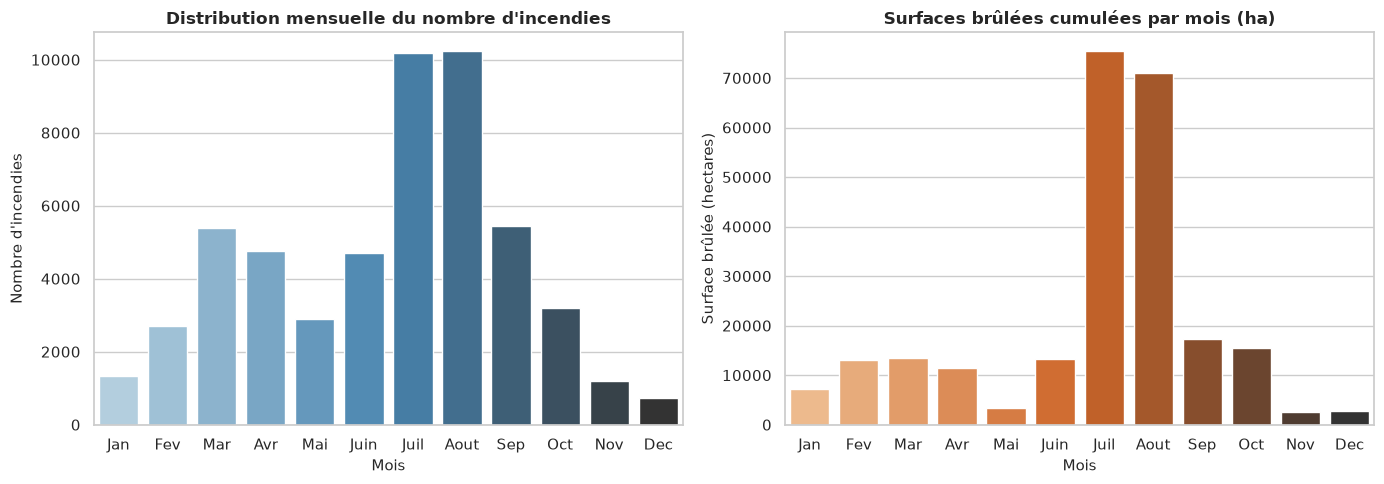

In [14]:
# Aggregation par mois
df_mensuel = (
    df.groupby("mois")
    .agg(
        nb_incendies=("surface_parcourue_m2", "count"),
        total_surface_ha=("surface_parcourue_ha", "sum")
    )
    .reset_index()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Nombre moyen/cumule d incendies par mois
sns.barplot( data=df_mensuel,
            x="mois",
            y="nb_incendies",
            palette="Blues_d",
            ax=ax1,
            hue="mois",
            legend=False
)

ax1.set_title( "Distribution mensuelle du nombre d'incendies", fontsize=12, fontweight="bold" )
ax1.set_xlabel("Mois", fontsize=11)
ax1.set_ylabel("Nombre d'incendies", fontsize=11)
ax1.set_xticks(range(12))
ax1.set_xticklabels(MONTH_NAMES)

# 2. Surface totale brulee par mois
sns.barplot(
    data=df_mensuel,
    x="mois",
    y="total_surface_ha",
    palette="Oranges_d",
    ax=ax2,
    hue="mois",
    legend=False
    )
ax2.set_title( "Surfaces brûlées cumulées par mois (ha)", fontsize=12, fontweight="bold" )
ax2.set_xlabel("Mois", fontsize=11)
ax2.set_ylabel("Surface brûlée (hectares)", fontsize=11)
ax2.set_xticks(range(12))
ax2.set_xticklabels(MONTH_NAMES)

plt.tight_layout()

### Distribution mensuelle

- **Pic estival prédominant** :<br>
Les mois de **juillet et août** constituent le cœur de la saison des feux<br>
totalisant chacun plus de **10 000 départs de feu** et plus de **70 000 ha brûlés**


- **Typologie des feux de printemps** :<br>
Un second pic d'activité apparaît en **mars et avril** (~5 000 incendies)<br>
mais avec des surfaces cumulées bien plus faibles (~13 000 ha)<br>
traduisant des départs plus vite maîtrisés ou des brûlages agricoles/pastoraux

### Distribution des surfaces brûlées (Échelle Log)

findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.

findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica Neue' not found.
findfont: Font family 'Arial' not found.

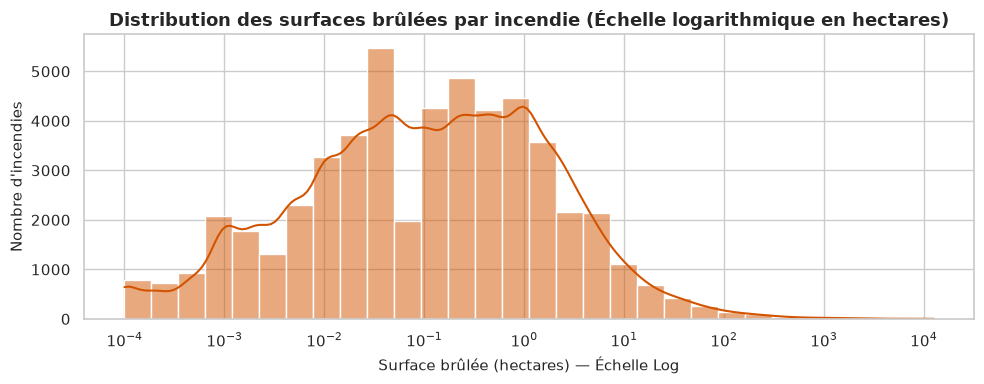

In [15]:
# Filtrage des feux avec surface > 0
df_pos = df[df["surface_parcourue_m2"] > 0].copy()

plt.figure(figsize=(10, 4))

# Distribution log-transformee
sns.histplot(
    data=df_pos,
    x="surface_parcourue_ha",
    log_scale=True,
    color="#d35400",
    kde=True,
    bins=30,
)

plt.title( "Distribution des surfaces brûlées par incendie (Échelle logarithmique en hectares)",
          fontsize=13,
          fontweight="bold"
)
plt.xlabel("Surface brûlée (hectares) — Échelle Log", fontsize=11)
plt.ylabel("Nombre d'incendies", fontsize=11)
plt.tight_layout()

### Distribution des surfaces brûlées (Échelle Log)



| Ordre de grandeur | Équivalence | description |
|---|---|---|
| $10^{-2}$ | $0{,}01 \text{ ha}$ ($100 \text{ m}^2$) | très petits départs de feu |
| $10^{-1}$ | $0{,}1 \text{ ha}$ ($1\ 000 \text{ m}^2$) | feux très rapidement maîtrisés |
| $10^0$ | $1 \text{ ha}$ ($10\ 000 \text{ m}^2$) | la majorité des incendies se concentre autour de cette valeur |
| $10^1$ | $10 \text{ ha}$ | incendies significatifs |
| $10^2$ | $100 \text{ ha}$ | grands feux |
| $10^3$ | $1\ 000 \text{ ha}$ | feux majeurs / mégafeux |


- **Forte dissymétrie des données** :<br>
La grande majorité des départs de feu est très localisée, se concentrant principalement entre **0,01 ha et 1 ha**

- **Poids des événements extrêmes** :<br>
Les incendies dépassant 100 à 1 000 hectares sont extrêmement rares dans la distribution<br>
mais ils représentent la quasi-totalité des surfaces détruites<br>
Cela confirme la nécessité d'appliquer une **transformation logarithmique** (`log1p`) sur la surface pour la modélisation

### Vacances et jours feriés

#### comparaison période de vacances vs hors vacances
- nombre moyen
- surface moyenne des incendies

In [16]:

# 1. Liste des années triées
years = sorted([int(y) for y in df['annee'].dropna().unique()])

# Fonction utilitaire pour calculer le résumé Vacances vs Hors Vacances
def get_vac_summary(df_sub):
    df_vac = df_sub.groupby('is_holyday').agg(
        nb_incendies=('surface_parcourue_ha', 'count'),
        surface_moyenne_ha=('surface_parcourue_ha', 'mean')
    ).reset_index()
    df_vac['Statut'] = df_vac['is_holyday'].map({True: 'Vacances scolaires', False: 'Hors vacances'})
    return df_vac

# 2. Création de la figure à 2 sous-graphiques (1 ligne, 2 colonnes)
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Nombre total d'incendies", "Surface moyenne par incendie (ha)")
)

couleurs = ['#2c3e50', '#e67e22']

# 3. Traces par défaut : "Toutes les années" (indices 0 et 1)
df_all = get_vac_summary(df)

fig.add_trace(
    go.Bar(
        x=df_all['Statut'],
        y=df_all['nb_incendies'],
        marker_color=couleurs,
        text=df_all['nb_incendies'],
        textposition='auto',
        name="Nombre total"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        x=df_all['Statut'],
        y=df_all['surface_moyenne_ha'].round(2),
        marker_color=couleurs,
        text=[f"{val:.2f} ha" for val in df_all['surface_moyenne_ha']],
        textposition='auto',
        name="Surface moyenne"
    ),
    row=1, col=2
)

# 4. Traces pour chaque année individuelle (masquées par défaut)
for year in years:
    df_y = get_vac_summary(df[df['annee'] == year])

    fig.add_trace(
        go.Bar(
            x=df_y['Statut'],
            y=df_y['nb_incendies'],
            marker_color=couleurs,
            text=df_y['nb_incendies'],
            textposition='auto',
            visible=False,
            name=f"Nombre {year}"
        ),
        row=1, col=1
    )

    fig.add_trace(
        go.Bar(
            x=df_y['Statut'],
            y=df_y['surface_moyenne_ha'].round(2),
            marker_color=couleurs,
            text=[f"{val:.2f} ha" for val in df_y['surface_moyenne_ha']],
            textposition='auto',
            visible=False,
            name=f"Surface {year}"
        ),
        row=1, col=2
    )

# 5. Construction des options du menu déroulant (updatemenus)
buttons = []

# Option 1 : Toutes les années
vis_all = [False] * (2 + 2 * len(years))
vis_all[0], vis_all[1] = True, True
buttons.append(dict(
    label="Toutes les années (2011-2025)",
    method="update",
    args=[{"visible": vis_all}, {"title.text": "Impact des Vacances Scolaires sur les Incendies (Cumul 2011-2025)"}]
))

# Options pour chaque année
for i, year in enumerate(years):
    vis_year = [False] * (2 + 2 * len(years))
    vis_year[2 + 2 * i] = True
    vis_year[2 + 2 * i + 1] = True
    buttons.append(dict(
        label=str(year),
        method="update",
        args=[{"visible": vis_year}, {"title.text": f"Impact des Vacances Scolaires sur les Incendies ({year})"}]
    ))

# 6. Finalisation de la mise en page
fig.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=1.02, y=1.15,
        xanchor='left',
        yanchor='top',
        showactive=True
    )],
    title_text="Impact des Vacances Scolaires sur les Incendies (Cumul 2011-2025)",
    title_x=0.05,
    showlegend=False,
    height=450,
    template="plotly_white"
)

fig.show()

In [17]:
# 1. Combinaison des indicateurs (Vacances OU Week-end OU Férié)
df['is_holy_or_off'] = df['is_day_off'] | df['is_holyday']

# 2. Agrégation par année et par type de période
df_grouped = (
    df.groupby(['annee', 'is_holy_or_off'])
    .agg(
        nb_incendies=('surface_parcourue_ha', 'count'),
        total_surface_ha=('surface_parcourue_ha', 'sum')
    )
    .reset_index()
)

# Séparation des deux sous-groupes
df_off = df_grouped[df_grouped['is_holy_or_off'] == True]
df_work = df_grouped[df_grouped['is_holy_or_off'] == False]

# 3. Création de la figure à 2 sous-graphiques (1 ligne, 2 colonnes)
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "Nombre d'incendies par an",
        "Surface totale brûlée par an (ha)"
    )
)

# --- Graphique 1 : Nombre d'incendies ---
fig.add_trace(
    go.Bar(
        x=df_off['annee'],
        y=df_off['nb_incendies'],
        name="Vacances / WE / Fériés",
        marker_color='#e67e22',
        hovertemplate="<b>%{x} (Repos/Vacances)</b><br />Incendies : %{y:,}"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        x=df_work['annee'],
        y=df_work['nb_incendies'],
        name="Jours ouvrés hors vacances",
        marker_color='#2c3e50',
        hovertemplate="<b>%{x} (Ouvrés)</b><br />Incendies : %{y:,}"
    ),
    row=1, col=1
)

# --- Graphique 2 : Surface totale brûlée (ha) ---
fig.add_trace(
    go.Bar(
        x=df_off['annee'],
        y=df_off['total_surface_ha'],
        name="Vacances / WE / Fériés",
        marker_color='#e67e22',
        showlegend=False,
        hovertemplate="<b>%{x} (Repos/Vacances)</b><br />Surface : %{y:,.1f} ha"
    ),
    row=1, col=2
)

fig.add_trace(
    go.Bar(
        x=df_work['annee'],
        y=df_work['total_surface_ha'],
        name="Jours ouvrés hors vacances",
        marker_color='#2c3e50',
        showlegend=False,
        hovertemplate="<b>%{x} (Ouvrés)</b><br />Surface : %{y:,.1f} ha"
    ),
    row=1, col=2
)

# 4. Mise en page globale
fig.update_layout(
    barmode='group',
    title_text="<b>Évolution annuelle (2011–2025) : Périodes de repos/vacances vs Jours ouvrés</b>",
    title_x=0.05,
    xaxis=dict(tickmode='linear', dtick=1, title="Année"),
    xaxis2=dict(tickmode='linear', dtick=1, title="Année"),
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(255, 255, 255, 0.8)'),
    template="plotly_white",
    height=500
)

fig.update_yaxes(title_text="Nombre d'incendies", row=1, col=1)
fig.update_yaxes(title_text="Surface brûlée (hectares)", row=1, col=2)

fig.show()